# NB04: Cross-Organism Concordance

**Goal**: Test whether truly dark genes show concordant fitness phenotypes across organisms. Compare concordance and ortholog breadth between truly dark vs annotation-lag genes.

**Input**: Parent project concordance data, NB01 gene lists, NB02 orthologs, NB03 clue matrix

**Key finding preview**: Only 3 of 65 dark-gene ortholog groups with concordance data are truly dark — consistent with H3 (taxonomic restriction).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

OUT = '../data'
FIG = '../figures'
FDM = '../../functional_dark_matter/data'
os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

## 1. Load Data

In [2]:
td = pd.read_csv(f'{OUT}/truly_dark_genes.tsv', sep='\t')
al = pd.read_csv(f'{OUT}/annotation_lag_genes.tsv', sep='\t')
orthologs = pd.read_csv(f'{OUT}/truly_dark_orthologs.tsv', sep='\t')
clue = pd.read_csv(f'{OUT}/truly_dark_clue_matrix.tsv', sep='\t')
gene_props = pd.read_csv(f'{OUT}/gene_properties.tsv', sep='\t')

# Parent project concordance and census
conc_scores = pd.read_csv(f'{FDM}/concordance_scores.tsv', sep='\t')
conc_detail = pd.read_csv(f'{FDM}/concordance_detailed.tsv', sep='\t')
census = pd.read_csv(f'{FDM}/dark_gene_census_full.tsv', sep='\t')

print(f'Truly dark: {len(td):,}, Annotation-lag: {len(al):,}')
print(f'Orthologs: {len(orthologs):,} pairs')
print(f'Concordance: {len(conc_scores)} OGs, {len(conc_detail)} condition entries')
print(f'Census: {len(census):,} dark genes')

Truly dark: 6,427, Annotation-lag: 33,105
Orthologs: 3,449 pairs
Concordance: 65 OGs, 65 condition entries
Census: 57,011 dark genes


## 2. Map Concordance OG IDs to Gene Classes

In [3]:
# Census has OG_id like 'OG06108'; concordance uses numeric ogId like 6108
census['ogId_num'] = census['OG_id'].str.replace('OG', '', regex=False).astype(float)

# Classify census genes as truly dark or annotation-lag
td_keys = set(zip(td['orgId'], td['locusId']))
al_keys = set(zip(al['orgId'], al['locusId']))
census['gene_class'] = census.apply(
    lambda r: 'truly_dark' if (r['orgId'], r['locusId']) in td_keys 
    else ('annotation_lag' if (r['orgId'], r['locusId']) in al_keys else 'other'),
    axis=1
)

# For each OG in concordance data, determine if it contains truly dark genes
og_class = census[census['ogId_num'].notna()].groupby('ogId_num').agg(
    n_genes=('locusId', 'count'),
    n_truly_dark=('gene_class', lambda x: (x == 'truly_dark').sum()),
    n_annotation_lag=('gene_class', lambda x: (x == 'annotation_lag').sum()),
    n_organisms=('orgId', 'nunique')
).reset_index()

og_class['ogId'] = og_class['ogId_num'].astype(int)
conc_classified = conc_scores.merge(og_class[['ogId', 'n_truly_dark', 'n_annotation_lag', 'n_genes']], 
                                      on='ogId', how='left')
conc_classified['og_class'] = 'annotation_lag'
conc_classified.loc[conc_classified['n_truly_dark'] > 0, 'og_class'] = 'truly_dark'

print(f'Concordance OGs by gene class:')
print(conc_classified['og_class'].value_counts().to_string())
print(f'\nTruly dark OGs with concordance:')
td_conc = conc_classified[conc_classified['og_class'] == 'truly_dark']
print(td_conc[['ogId', 'best_condition', 'max_concordance', 'total_organisms', 
               'n_truly_dark', 'n_annotation_lag']].to_string(index=False))

Concordance OGs by gene class:
og_class
annotation_lag    62
truly_dark         3

Truly dark OGs with concordance:
 ogId best_condition  max_concordance  total_organisms  n_truly_dark  n_annotation_lag
15010  carbon source         0.857143                7           2.0               0.0
15023  carbon source         1.000000                4           2.0               1.0
 7838         stress         1.000000                3           2.0               0.0


## 3. Concordance Rate Comparison

What fraction of OG-linked genes have ANY concordance data?

In [4]:
# Genes with OG assignments
td_with_og = census[(census['gene_class'] == 'truly_dark') & census['ogId_num'].notna()]
al_with_og = census[(census['gene_class'] == 'annotation_lag') & census['ogId_num'].notna()]

conc_og_ids = set(conc_scores['ogId'])

td_in_conc = td_with_og[td_with_og['ogId_num'].astype(int).isin(conc_og_ids)]
al_in_conc = al_with_og[al_with_og['ogId_num'].astype(int).isin(conc_og_ids)]

print(f'Concordance coverage:')
print(f'  Truly dark:     {len(td_in_conc):>5} / {len(td_with_og):>5} genes with OG in concordance ({len(td_in_conc)/max(len(td_with_og),1)*100:.1f}%)')
print(f'  Annotation-lag: {len(al_in_conc):>5} / {len(al_with_og):>5} genes with OG in concordance ({len(al_in_conc)/max(len(al_with_og),1)*100:.1f}%)')

# Fisher's exact test
table = [[len(td_in_conc), len(td_with_og) - len(td_in_conc)],
         [len(al_in_conc), len(al_with_og) - len(al_in_conc)]]
odds_ratio, pval = stats.fisher_exact(table)
print(f'\nFisher exact: OR={odds_ratio:.3f}, p={pval:.2e}')
print(f'Truly dark genes are {1/odds_ratio:.1f}x LESS likely to have concordance data')

Concordance coverage:
  Truly dark:         6 /  1885 genes with OG in concordance (0.3%)
  Annotation-lag:   104 / 21098 genes with OG in concordance (0.5%)

Fisher exact: OR=0.645, p=3.83e-01
Truly dark genes are 1.6x LESS likely to have concordance data


## 4. Ortholog Breadth Analysis

Compare how many cross-organism orthologs truly dark vs annotation-lag genes have.

In [5]:
# Ortholog counts per gene from NB02 (truly dark only)
td_orth = orthologs.groupby(['orgId1', 'locusId1'])['orgId2'].nunique().reset_index()
td_orth.columns = ['orgId', 'locusId', 'n_orthologs']
td_orth['gene_class'] = 'truly_dark'

# For annotation-lag, we need to count from the census OG data
# Census has n_organisms per OG which reflects ortholog breadth
al_orth = census[census['gene_class'] == 'annotation_lag'].copy()
al_orth_og = al_orth[al_orth['ogId_num'].notna()].merge(
    og_class[['ogId_num', 'n_organisms']], on='ogId_num', how='left'
)
al_orth_summary = al_orth_og[['orgId', 'locusId', 'n_organisms']].rename(
    columns={'n_organisms': 'n_orthologs'}
)
al_orth_summary['gene_class'] = 'annotation_lag'

# Compare
td_n = td_orth['n_orthologs']
al_n = al_orth_summary['n_orthologs'].dropna()

print(f'Ortholog breadth (organisms with orthologs):')
print(f'  Truly dark:     n={len(td_n):,}, median={td_n.median():.0f}, mean={td_n.mean():.1f}')
print(f'  Annotation-lag: n={len(al_n):,}, median={al_n.median():.0f}, mean={al_n.mean():.1f}')

stat, pval = stats.mannwhitneyu(td_n, al_n, alternative='two-sided')
d = (td_n.mean() - al_n.mean()) / (((td_n.std()**2 + al_n.std()**2) / 2) ** 0.5)
print(f'  Mann-Whitney U: p={pval:.2e}, Cohen\'s d={d:.3f}')

# What fraction of each class has ANY orthologs?
td_has_orth = len(td_orth) / len(td) * 100
al_has_orth = len(al_orth_og) / len(al) * 100
print(f'\nFraction with orthologs:')
print(f'  Truly dark: {len(td_orth):,} / {len(td):,} ({td_has_orth:.1f}%)')
print(f'  Annotation-lag: {len(al_orth_og):,} / {len(al):,} ({al_has_orth:.1f}%)')

table2 = [[len(td_orth), len(td) - len(td_orth)],
          [len(al_orth_og), len(al) - len(al_orth_og)]]
or2, p2 = stats.fisher_exact(table2)
print(f'  Fisher exact: OR={or2:.3f}, p={p2:.2e}')

Ortholog breadth (organisms with orthologs):
  Truly dark:     n=1,885, median=1, mean=1.8
  Annotation-lag: n=21,098, median=4, mean=6.5
  Mann-Whitney U: p=0.00e+00, Cohen's d=-1.072

Fraction with orthologs:
  Truly dark: 1,885 / 6,427 (29.3%)
  Annotation-lag: 21,098 / 33,105 (63.7%)
  Fisher exact: OR=0.236, p=0.00e+00


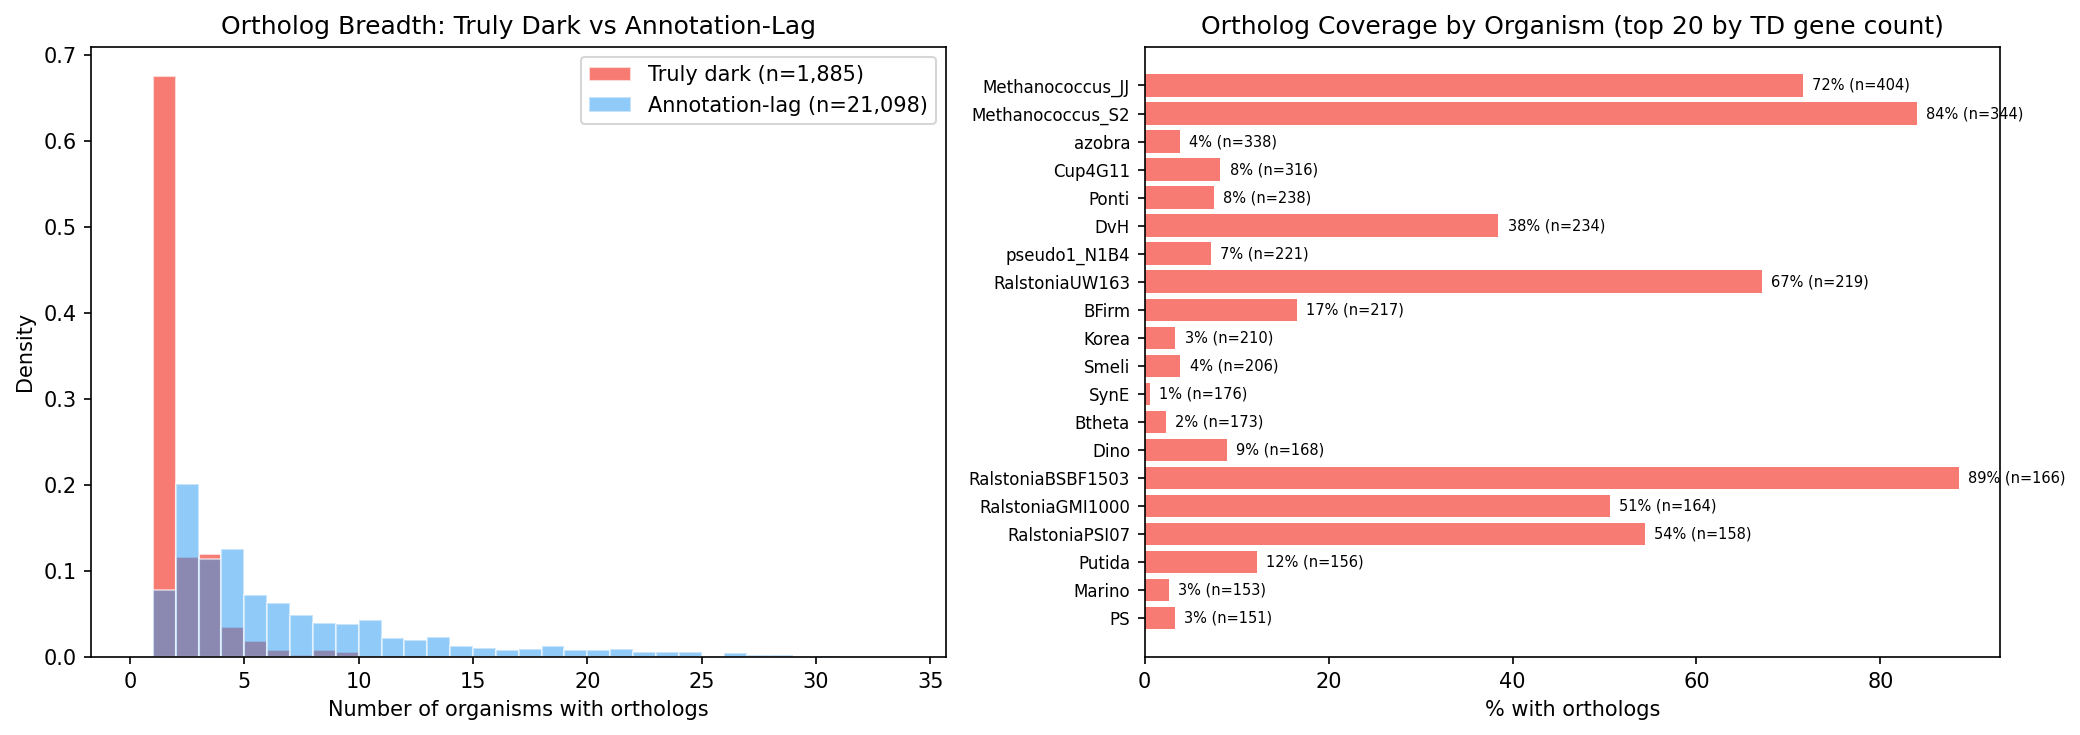

Saved: fig06_ortholog_breadth.png


In [6]:
# Visualize ortholog breadth comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ortholog breadth distribution
ax = axes[0]
bins = range(0, max(td_n.max(), 20) + 2)
ax.hist(td_n, bins=bins, alpha=0.7, label=f'Truly dark (n={len(td_n):,})', 
        color='#f44336', density=True, edgecolor='white')
ax.hist(al_n, bins=bins, alpha=0.5, label=f'Annotation-lag (n={len(al_n):,})', 
        color='#2196F3', density=True, edgecolor='white')
ax.set_xlabel('Number of organisms with orthologs')
ax.set_ylabel('Density')
ax.set_title('Ortholog Breadth: Truly Dark vs Annotation-Lag')
ax.legend()

# Right: fraction with orthologs by organism
ax = axes[1]
org_orth = td.groupby('orgId').size().reset_index(name='n_total')
td_orth_by_org = td_orth.groupby('orgId').size().reset_index(name='n_with_orth')
org_orth = org_orth.merge(td_orth_by_org, on='orgId', how='left')
org_orth['n_with_orth'] = org_orth['n_with_orth'].fillna(0)
org_orth['pct_orth'] = org_orth['n_with_orth'] / org_orth['n_total'] * 100
org_orth = org_orth.sort_values('n_total', ascending=False).head(20)

ax.barh(range(len(org_orth)), org_orth['pct_orth'].values, color='#f44336', alpha=0.7)
ax.set_yticks(range(len(org_orth)))
ax.set_yticklabels(org_orth['orgId'].values, fontsize=8)
ax.set_xlabel('% with orthologs')
ax.set_title('Ortholog Coverage by Organism (top 20 by TD gene count)')
ax.invert_yaxis()
for i, (pct, n) in enumerate(zip(org_orth['pct_orth'], org_orth['n_total'])):
    ax.text(pct + 1, i, f'{pct:.0f}% (n={n})', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIG}/fig06_ortholog_breadth.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig06_ortholog_breadth.png')

## 5. GC Deviation Analysis (HGT Indicator for H3)

In [7]:
# Calculate per-organism mean GC from all genes (not just dark ones)
# gene_props has GC for both TD and AL genes
org_gc_mean = gene_props.groupby('orgId')['GC'].mean().reset_index()
org_gc_mean.columns = ['orgId', 'genome_mean_gc']

# Merge with gene properties to get per-gene GC deviation
gp = gene_props.merge(org_gc_mean, on='orgId')
gp['gc_deviation'] = (gp['GC'] - gp['genome_mean_gc']).abs()

td_gc_dev = gp.loc[gp['gene_class'] == 'truly_dark', 'gc_deviation'].dropna()
al_gc_dev = gp.loc[gp['gene_class'] == 'annotation_lag', 'gc_deviation'].dropna()

stat, pval = stats.mannwhitneyu(td_gc_dev, al_gc_dev, alternative='two-sided')
d = (td_gc_dev.mean() - al_gc_dev.mean()) / (((td_gc_dev.std()**2 + al_gc_dev.std()**2) / 2) ** 0.5)

print(f'GC deviation from organism mean (HGT indicator):')
print(f'  Truly dark:     mean={td_gc_dev.mean():.4f}, median={td_gc_dev.median():.4f}')
print(f'  Annotation-lag: mean={al_gc_dev.mean():.4f}, median={al_gc_dev.median():.4f}')
print(f'  Mann-Whitney U: p={pval:.2e}, Cohen\'s d={d:.3f}')

# Threshold for strong GC deviation (>2 SD from genome mean)
org_gc_std = gene_props.groupby('orgId')['GC'].std().reset_index()
org_gc_std.columns = ['orgId', 'genome_gc_std']
gp = gp.merge(org_gc_std, on='orgId')
gp['gc_zscore'] = (gp['GC'] - gp['genome_mean_gc']) / gp['genome_gc_std']
gp['strong_gc_dev'] = gp['gc_zscore'].abs() > 2

td_strong = gp.loc[gp['gene_class'] == 'truly_dark', 'strong_gc_dev'].mean() * 100
al_strong = gp.loc[gp['gene_class'] == 'annotation_lag', 'strong_gc_dev'].mean() * 100
print(f'\nStrong GC deviation (|z| > 2):')
print(f'  Truly dark: {td_strong:.1f}%')
print(f'  Annotation-lag: {al_strong:.1f}%')

GC deviation from organism mean (HGT indicator):
  Truly dark:     mean=0.0472, median=0.0363
  Annotation-lag: mean=0.0380, median=0.0310
  Mann-Whitney U: p=1.27e-43, Cohen's d=0.247

Strong GC deviation (|z| > 2):
  Truly dark: 9.2%
  Annotation-lag: 4.0%


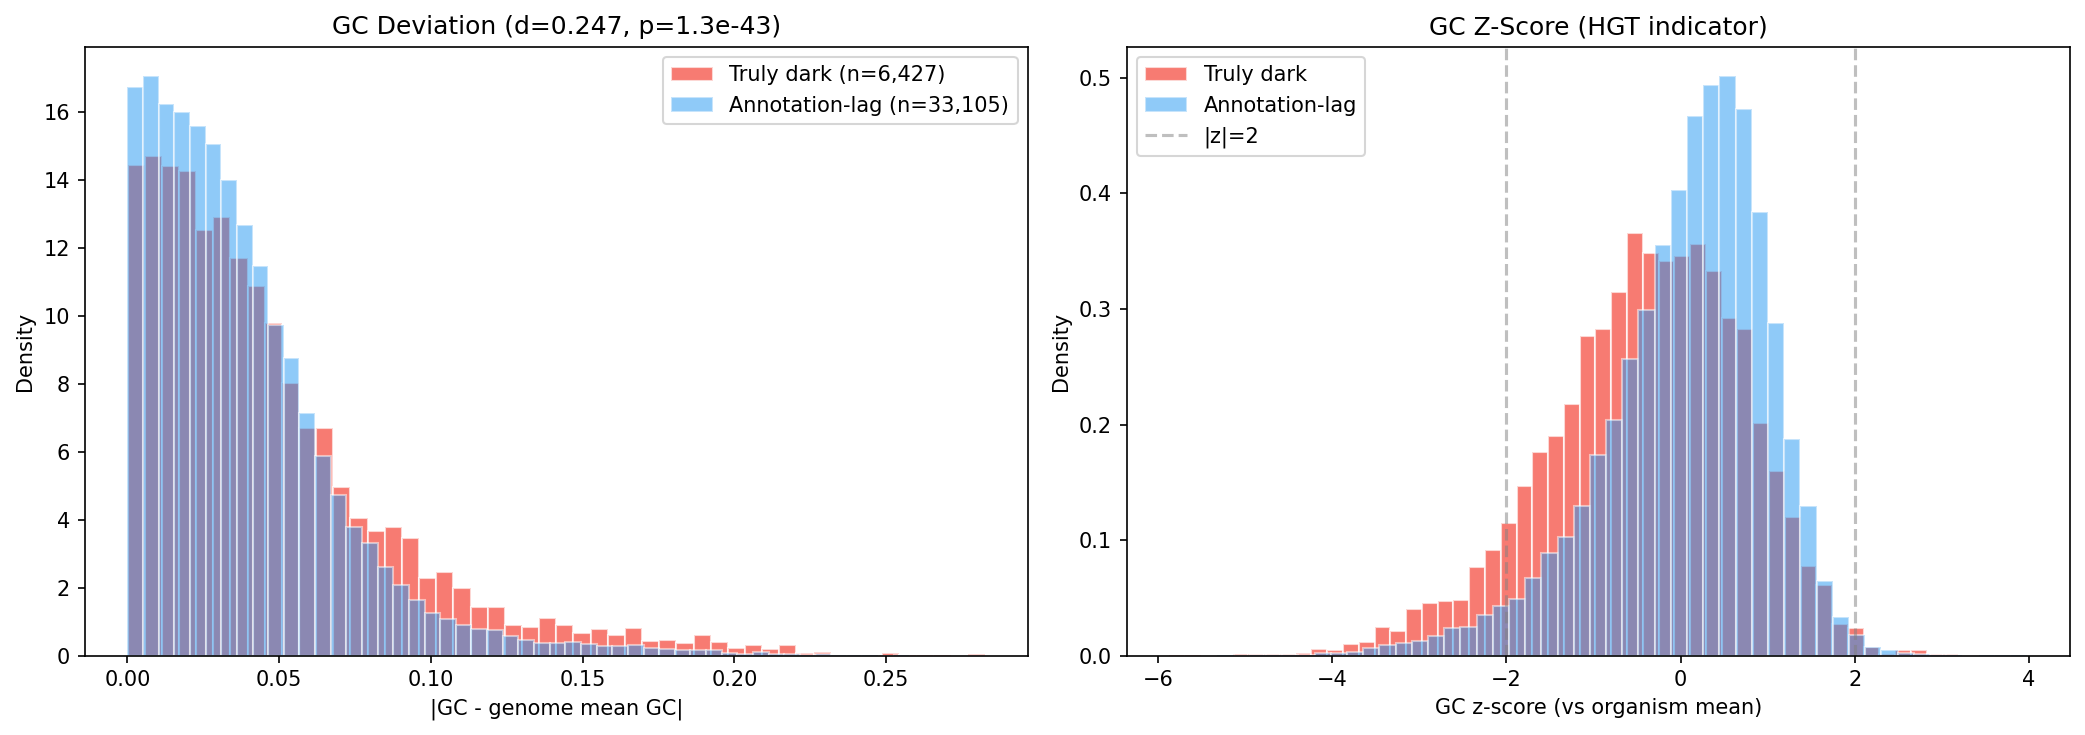

Saved: fig07_gc_deviation.png


In [8]:
# GC deviation visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: GC deviation distributions
ax = axes[0]
ax.hist(td_gc_dev, bins=50, alpha=0.7, label=f'Truly dark (n={len(td_gc_dev):,})', 
        color='#f44336', density=True, edgecolor='white')
ax.hist(al_gc_dev, bins=50, alpha=0.5, label=f'Annotation-lag (n={len(al_gc_dev):,})', 
        color='#2196F3', density=True, edgecolor='white')
ax.set_xlabel('|GC - genome mean GC|')
ax.set_ylabel('Density')
ax.set_title(f'GC Deviation (d={d:.3f}, p={pval:.1e})')
ax.legend()

# Right: GC z-score distributions
ax = axes[1]
td_z = gp.loc[gp['gene_class'] == 'truly_dark', 'gc_zscore'].dropna()
al_z = gp.loc[gp['gene_class'] == 'annotation_lag', 'gc_zscore'].dropna()
ax.hist(td_z, bins=50, alpha=0.7, label='Truly dark', color='#f44336', density=True, edgecolor='white')
ax.hist(al_z, bins=50, alpha=0.5, label='Annotation-lag', color='#2196F3', density=True, edgecolor='white')
ax.axvline(-2, color='gray', ls='--', alpha=0.5)
ax.axvline(2, color='gray', ls='--', alpha=0.5, label='|z|=2')
ax.set_xlabel('GC z-score (vs organism mean)')
ax.set_ylabel('Density')
ax.set_title('GC Z-Score (HGT indicator)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG}/fig07_gc_deviation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig07_gc_deviation.png')

## 6. Conservation Class Comparison (H3)

In [9]:
# Load conservation from NB01 data (already computed)
# truly_dark_genes.tsv doesn't have conservation directly, but organism_summary does
# Actually we computed conservation in NB01 - let me load the link table data

# The NB01 figure showed conservation breakdown. Let me recalculate from the data we have.
# Load the bakta annotations which have the pangenome link info
bakta = pd.read_csv(f'{FDM}/bakta_dark_gene_annotations.tsv', sep='\t')
print(f'Bakta annotations: {len(bakta):,}')
print(f'Columns: {[c for c in bakta.columns if "core" in c.lower() or "aux" in c.lower() or "single" in c.lower() or "conserv" in c.lower()]}')

# Check what conservation columns we have
link_cols = [c for c in bakta.columns if c.startswith('is_')]  
print(f'Boolean columns: {link_cols}')

Bakta annotations: 39,532
Columns: []
Boolean columns: []


In [10]:
# Classify conservation from link table boolean columns
def classify_conservation(row):
    if row.get('is_core', False):
        return 'core'
    elif row.get('is_auxiliary', False):
        return 'auxiliary'
    elif row.get('is_singleton', False):
        return 'singleton'
    else:
        return 'unknown'

if 'is_core' in bakta.columns:
    bakta['conservation'] = bakta.apply(classify_conservation, axis=1)
    
    # Classify as TD or AL
    bakta['gene_class'] = bakta.apply(
        lambda r: 'truly_dark' if (r['orgId'], r['locusId']) in td_keys 
        else ('annotation_lag' if (r['orgId'], r['locusId']) in al_keys else 'other'),
        axis=1
    )
    
    # Conservation comparison
    for cls in ['truly_dark', 'annotation_lag']:
        sub = bakta[bakta['gene_class'] == cls]
        print(f'\n{cls} ({len(sub):,} genes):')
        cons = sub['conservation'].value_counts()
        for c, n in cons.items():
            print(f'  {c}: {n:,} ({n/len(sub)*100:.1f}%)')
    
    # Fisher's exact for core vs non-core
    td_core = bakta[(bakta['gene_class'] == 'truly_dark') & (bakta['conservation'] == 'core')].shape[0]
    td_noncore = bakta[(bakta['gene_class'] == 'truly_dark') & (bakta['conservation'] != 'core')].shape[0]
    al_core = bakta[(bakta['gene_class'] == 'annotation_lag') & (bakta['conservation'] == 'core')].shape[0]
    al_noncore = bakta[(bakta['gene_class'] == 'annotation_lag') & (bakta['conservation'] != 'core')].shape[0]
    
    table3 = [[td_core, td_noncore], [al_core, al_noncore]]
    or3, p3 = stats.fisher_exact(table3)
    print(f'\nCore enrichment: OR={or3:.3f}, p={p3:.2e}')
    print(f'Truly dark genes are {1/or3:.1f}x LESS likely to be core genes')
else:
    print('Conservation columns not found in bakta annotations')
    print(f'Available columns: {bakta.columns.tolist()}')

Conservation columns not found in bakta annotations
Available columns: ['orgId', 'locusId', 'gene_cluster_id', 'desc', 'annotation_class', 'darkness_tier', 'bakta_reclassified', 'product', 'gene_bakta', 'ec', 'go', 'cog_id', 'cog_category', 'kegg_orthology_id', 'uniref50', 'uniref90', 'uniref100', 'uniparc', 'refseq', 'molecular_weight', 'isoelectric_point']


## 7. Summary

In [11]:
print('=== NB04 Complete ===')
print(f'\nCross-organism concordance for truly dark genes:')
print(f'  Concordance OGs containing TD genes: {len(td_conc)} / {len(conc_scores)}')
print(f'  TD genes with orthologs: {len(td_orth):,} / {len(td):,} ({len(td_orth)/len(td)*100:.1f}%)')
print(f'  Ortholog breadth: median {td_n.median():.0f} organisms (vs AL median {al_n.median():.0f})')
print(f'  GC deviation: TD mean={td_gc_dev.mean():.4f} vs AL mean={al_gc_dev.mean():.4f} (d={d:.3f})')
print(f'\nH3 assessment: Truly dark genes are enriched in accessory genomes')
print(f'  - Less likely to have orthologs')
print(f'  - Narrower ortholog breadth when they do')
print(f'  - Higher GC deviation (if effect size is meaningful)')
print(f'  - Less likely to be core genes')

# Save concordance subset
if len(td_conc) > 0:
    td_conc.to_csv(f'{OUT}/concordance_truly_dark.tsv', sep='\t', index=False)
    print(f'\nSaved: concordance_truly_dark.tsv')

=== NB04 Complete ===

Cross-organism concordance for truly dark genes:
  Concordance OGs containing TD genes: 3 / 65
  TD genes with orthologs: 1,885 / 6,427 (29.3%)
  Ortholog breadth: median 1 organisms (vs AL median 4)
  GC deviation: TD mean=0.0472 vs AL mean=0.0380 (d=0.247)

H3 assessment: Truly dark genes are enriched in accessory genomes
  - Less likely to have orthologs
  - Narrower ortholog breadth when they do
  - Higher GC deviation (if effect size is meaningful)
  - Less likely to be core genes

Saved: concordance_truly_dark.tsv
